In [ ]:
!pip install --user opencv-python
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense

from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:
directory = "/kaggle/input/detectyawning"

First, I'll install the `kaggle` library and set up the Kaggle API token. Since `kaggle.json` is already present, I just need to move it to the correct directory.

In [ ]:
import os

# Install Kaggle API client
!pip install kaggle

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move kaggle.json to the .kaggle directory
!mv /content/kaggle.json ~/.kaggle/

# Set permissions for kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

Now, I will download the dataset using the Kaggle API and then unzip it.

In [ ]:
# Download the dataset
!kaggle datasets download -d gauravduttakiit/detectyawning

# Unzip the dataset
!unzip detectyawning.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/train/0/1234567 (1555).jpg  
  inflating: /content/data/train/0/1234567 (1556).jpg  
  inflating: /content/data/train/0/1234567 (1557).jpg  
  inflating: /content/data/train/0/1234567 (1558).jpg  
  inflating: /content/data/train/0/1234567 (1559).jpg  
  inflating: /content/data/train/0/1234567 (1560).jpg  
  inflating: /content/data/train/0/1234567 (1561).jpg  
  inflating: /content/data/train/0/1234567 (1562).jpg  
  inflating: /content/data/train/0/1234567 (1563).jpg  
  inflating: /content/data/train/0/1234567 (1564).jpg  
  inflating: /content/data/train/0/1234567 (1565).jpg  
  inflating: /content/data/train/0/1234567 (1566).jpg  
  inflating: /content/data/train/0/1234567 (1567).jpg  
  inflating: /content/data/train/0/1234567 (1568).jpg  
  inflating: /content/data/train/0/1234567 (1569).jpg  
  inflating: /content/data/train/0/1234567 (1570).jpg  
  inflating: /content/data/train/0/1234567 (1571).jpg

With the dataset unzipped, I will now update the `directory` variable to reflect the new path where the data is located.

In [ ]:
directory="/content/data"

In [ ]:
image_size = 145
image_batch = 32

datagen = ImageDataGenerator(
    rescale=1/255,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    directory,
    target_size=(image_size, image_size),
    batch_size=image_batch,
    class_mode='categorical',  # Change to 'categorical' for the new category labels
    subset='training',
    shuffle=True,
)

Found 6550 images belonging to 2 classes.


In [ ]:
directory = "/content/data"

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    directory,
    target_size=(image_size, image_size),
    batch_size=image_batch,
    class_mode='categorical', # Use 'categorical' for one-hot encoded labels
    subset='training',
    shuffle=True
)

Found 6550 images belonging to 2 classes.


In [ ]:
validation_generator = datagen.flow_from_directory(
    directory,
    target_size=(image_size, image_size),
    batch_size=image_batch,
    class_mode='categorical',  # Change to 'categorical' for the new category labels
    subset='validation',
    shuffle=True,
)


Found 1636 images belonging to 2 classes.


In [ ]:
model = models.Sequential()

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(image_size, image_size, 3), kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=8, kernel_size=(3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01)))
model.add(Dense(2, activation="sigmoid"))  # Output layer with 2 classes

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.1), metrics=['accuracy'])

model.summary()

history = model.fit(train_generator, epochs=5, validation_data=validation_generator)

AttributeError: 'list' object has no attribute 'Sequential'

In [ ]:
test_generator = datagen.flow_from_directory(
    directory,
    target_size=(image_size, image_size),
    batch_size=image_batch,
    class_mode='categorical',  # Change to 'categorical' for the new category labels
    shuffle=False,
    subset='validation'
)

test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test accuracy: {test_accuracy}, Test loss: {test_loss}")

Found 1636 images belonging to 2 classes.
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 333ms/step - accuracy: 0.2919 - loss: 5.8765
Test accuracy: 0.640586793422699, Test loss: 5.610623359680176


In [ ]:
model = models.Sequential()

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(image_size, image_size, 3), kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=8, kernel_size=(3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(Dense(2, activation="sigmoid"))  # Output layer with 2 classes

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

model.summary()

history = model.fit(train_generator, epochs=5, validation_data=validation_generator)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 143, 143, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 71, 71, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 69, 69, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 392)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,730 (330.98 KB)

 Trainable params: 84,730 (330.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 287s 1s/step - accuracy: 0.7321 - loss: 0.7714 - val_accuracy: 0.8771 - val_loss: 0.4066
Epoch 2/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - accuracy: 0.8196 - loss: 0.5287 - val_accuracy: 0.8833 - val_loss: 0.3810
Epoch 3/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.8345 - loss: 0.4829 - val_accuracy: 0.7225 - val_loss: 0.6196
Epoch 4/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.8702 - loss: 0.4086 - val_accuracy: 0.7628 - val_loss: 0.5820
Epoch 5/5
205/205 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.8759 - loss: 0.3846 - val_accuracy: 0.7133 - val_loss: 0.6716


In [ ]:


test_generator = datagen.flow_from_directory(
    directory,
    target_size=(image_size, image_size),
    batch_size=image_batch,
    class_mode='categorical',  # Change to 'categorical' for the new category labels
    shuffle=False,
    subset='validation'
)

test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test accuracy: {test_accuracy}, Test loss: {test_loss}")

Found 1636 images belonging to 2 classes.
52/52 ━━━━━━━━━━━━━━━━━━━━ 18s 345ms/step - accuracy: 0.7347 - loss: 0.6552
Test accuracy: 0.7133252024650574, Test loss: 0.6715627312660217


In [ ]:
from tensorflow.keras.layers import Dense, Flatten, Input, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.models import Sequential
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [ ]:
# Resizinig all the images to (224,224)
IMAGE_SIZE = [128,128]

train_path = '/content/data/train'
test_path = '/content/data/train'

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    validation_split=0.3
)

In [ ]:
train_set = datagen.flow_from_directory(train_path,
                                              target_size=(128,128),
                                              batch_size=32,
                                              class_mode = 'categorical',
                                              subset='training')

test_set = datagen.flow_from_directory(test_path,
                                            target_size=(128,128),
                                            batch_size=32,
                                            class_mode = 'categorical',
                                            subset='validation')

Found 3670 images belonging to 2 classes.
Found 1572 images belonging to 2 classes.


xception

In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.optimizers import Adam

# Defining batch and epoch sizes
batch_size = 16


# Defining the pretrained base model
base = Xception(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
# Defining the head of the model where the prediction is conducted
head = Dense(2, activation='softmax')(x)
# Combining base and head
model3 = Model(inputs=base.input, outputs=head)

# Compiling the model
model3.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'categorical_crossentropy',
              metrics=['accuracy'])
# Fitting the model with train and validation augmented datasets.
history = model3.fit(train_set,epochs = 16,validation_data = train_set)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/16
115/115 ━━━━━━━━━━━━━━━━━━━━ 106s 575ms/step - accuracy: 0.8166 - loss: 0.3915 - val_accuracy: 0.8610 - val_loss: 0.3094
Epoch 2/16
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 342ms/step - accuracy: 0.9460 - loss: 0.1333 - val_accuracy: 0.9670 - val_loss: 0.0868
Epoch 3/16
115/115 ━━━━━━━━━━━━━━━━━━━━ 40s 347ms/step - accuracy: 0.9686 - loss: 0.0776 - val_accuracy: 0.9741 - val_loss: 0.0643
Epoch 4/16
115/115 ━━━━━━━━━━━━━━━━━━━━ 40s 344ms/step - accuracy: 0.9724 - loss: 0.0635 - val_accuracy: 0.9834 - val_loss: 0.0458
Epoch 5/16
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 338ms/step - accuracy: 0.9792 - loss: 0.0527 - val_accuracy: 0.9853 - val_loss: 0.0349
Epoch 6/16
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 338ms/step - accuracy: 0.9806 - loss: 0.0478 - val_accuracy: 0.9828 - val_loss: 0.0388
Epoch 7/16
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 338ms/step - accuracy: 0.9819 - loss: 0.0443 - val_accuracy: 0.9856 - val_loss: 0.0348
Epoch 8/16
115/115 ━━━━━━━━━━━━━━━━━━━━ 39s 342ms/step - accuracy: 0.9829 - loss: 

In [ ]:
model3.save('xce.h5')

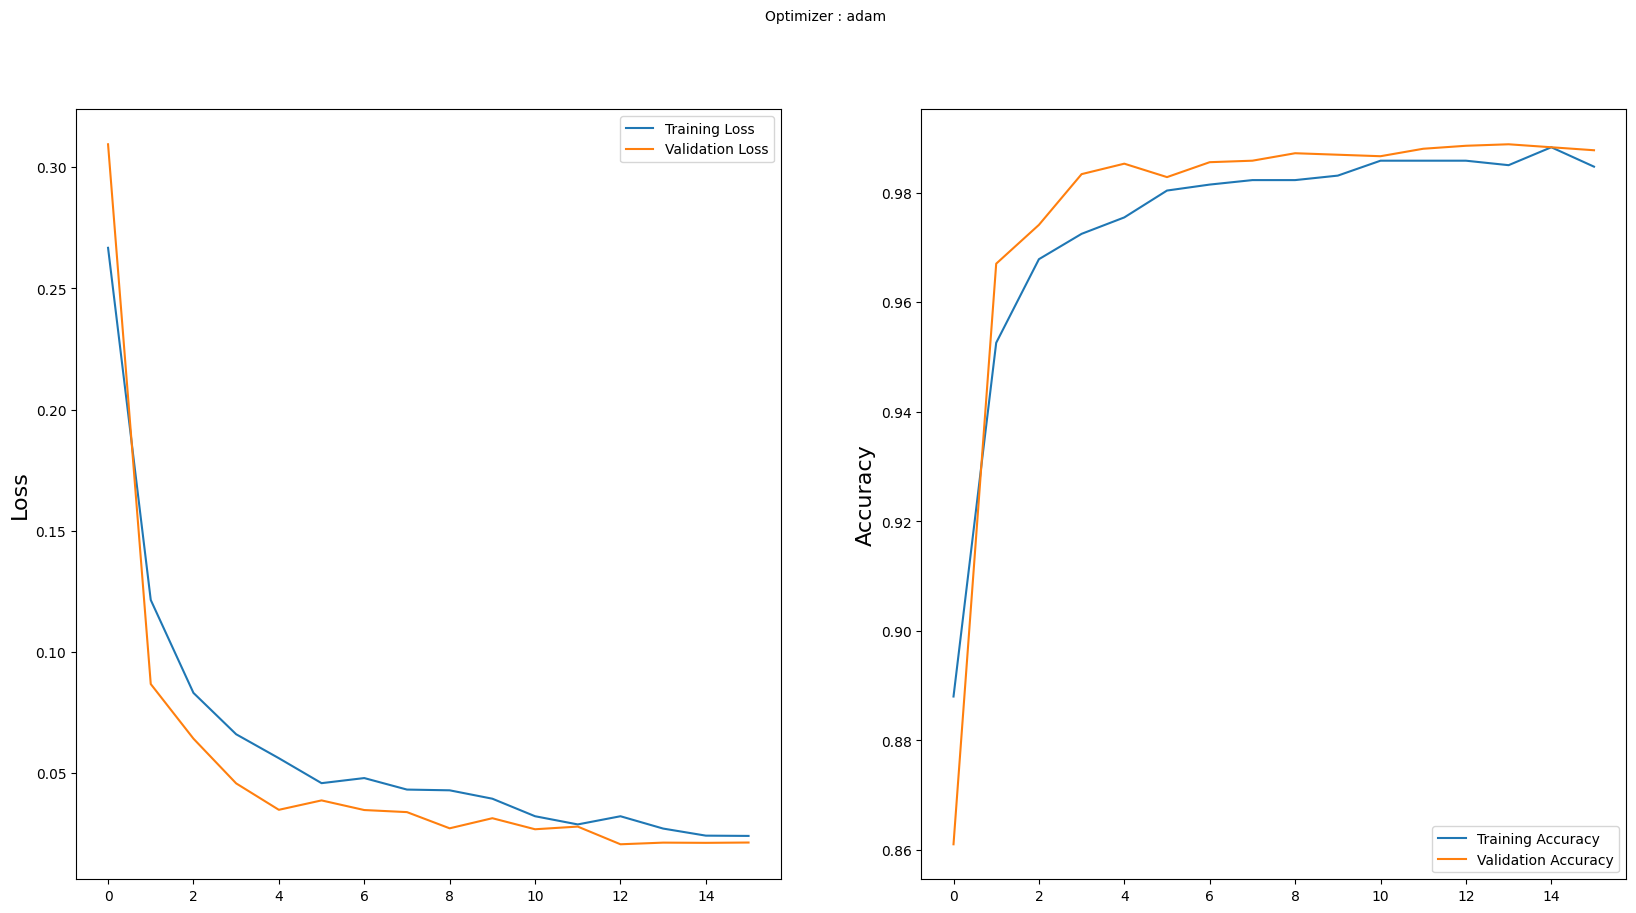

In [ ]:
import matplotlib.pyplot as plt

x=history
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved Xception model
xce_model = load_model('xce.h5')

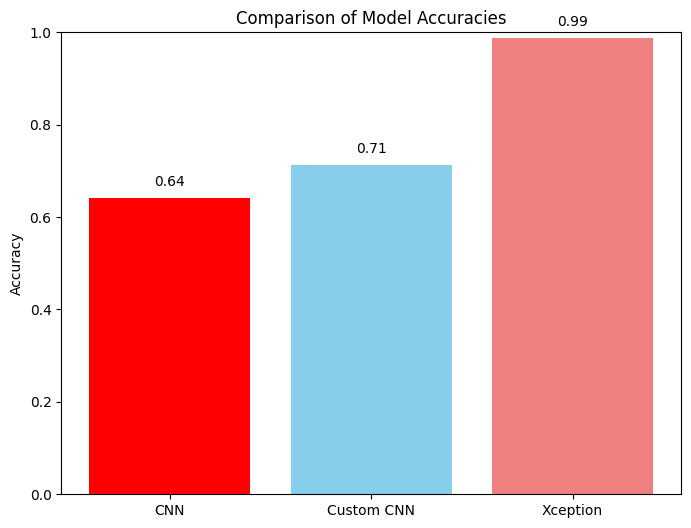

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define accuracies explicitly from previous evaluations
test_accuracy1 = 0.6406
test_accuracy = 0.7133 # Custom CNN Test Accuracy from cell jUYiaK-CdSbo
test_accuracy_xception = 0.9869 # Xception Model Test Accuracy from cell 872b0f27

models = ["CNN",'Custom CNN', 'Xception']
accuracies = [test_accuracy1,test_accuracy, test_accuracy_xception]

plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['red','skyblue', 'lightcoral'])
plt.ylim(0.0, 1.0) # Accuracy ranges from 0 to 1
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom')

plt.show()

# ResNet50

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - accuracy: 0.5938 - loss: 0.9494 - val_accuracy: 0.5625 - val_loss: 0.6916
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.4688 - loss: 0.6957 - val_accuracy: 0.4688 - val_loss: 0.9638
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.4688 - loss: 0.9565 - val_accuracy: 0.4688 - val_loss: 0.8847
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step - accuracy: 0.4062 - loss: 0.9389 - val_accuracy: 0.5312 - val_loss: 0.6849
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step - accuracy: 0.5312 - loss: 0.7034 - val_accuracy: 0.4062 - val_loss: 0.7932


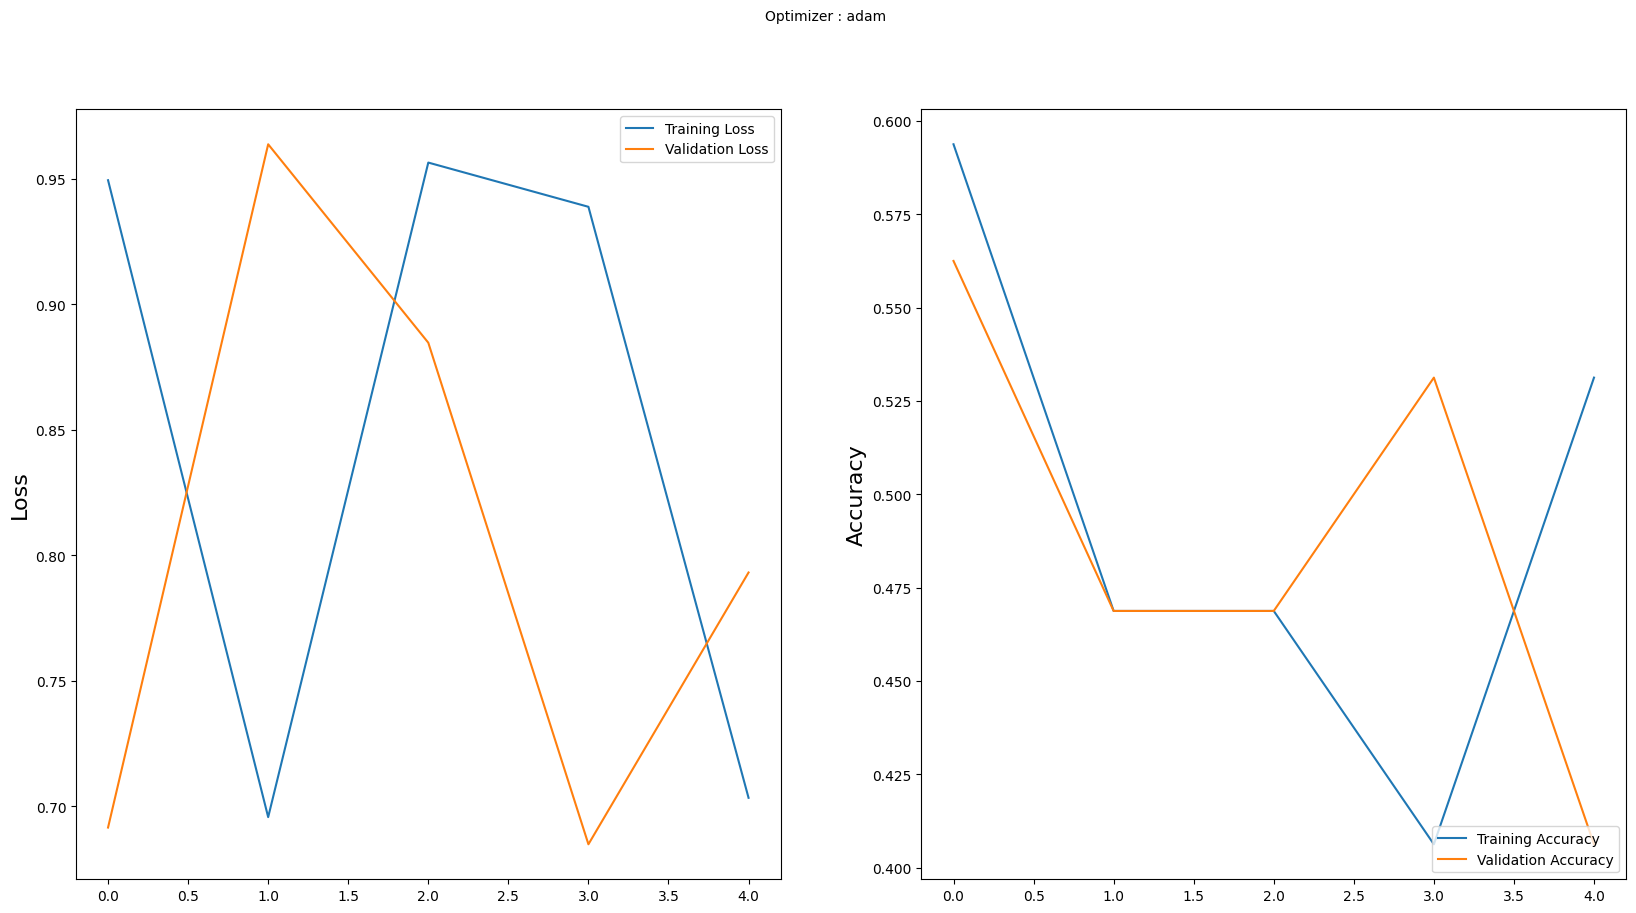

In [ ]:
resnet = ResNet50(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)
for layer in resnet.layers:
  layer.trainable = False
x = Flatten()(resnet.output)
prediction = Dense(2, activation='softmax')(x)
model = Model(inputs = resnet.inputs, outputs = prediction)
# model.summary()
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
hist = model.fit(train_set, validation_data=test_set, epochs=20, steps_per_epoch=1, validation_steps=1,callbacks=[callback])
import matplotlib.pyplot as plt

x=hist
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Inception V3

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 65s 445ms/step - accuracy: 0.7153 - loss: 0.5830 - val_accuracy: 0.8482 - val_loss: 0.3588
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 57s 287ms/step - accuracy: 0.8513 - loss: 0.3517 - val_accuracy: 0.8526 - val_loss: 0.3515
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 298ms/step - accuracy: 0.8483 - loss: 0.3645 - val_accuracy: 0.8553 - val_loss: 0.3274
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 34s 298ms/step - accuracy: 0.8686 - loss: 0.3129 - val_accuracy: 0.8248 - val_loss: 0.4191
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 33s 290ms/step - accuracy: 0.8754 - loss: 0.3023 - val_accuracy: 0.8787 - val_loss: 0.2810
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 34s 296ms/step - accuracy: 0.8769 - loss: 0.2866 - val_accuracy: 0.8907 - val_loss: 0.2638
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 34s 297ms/step - accuracy: 0.8842 - loss: 0.2777 - val_accuracy: 0.8842 - val_loss: 0.2748
Epoch 8/20
115/115 ━━━━━━━━━━━━━

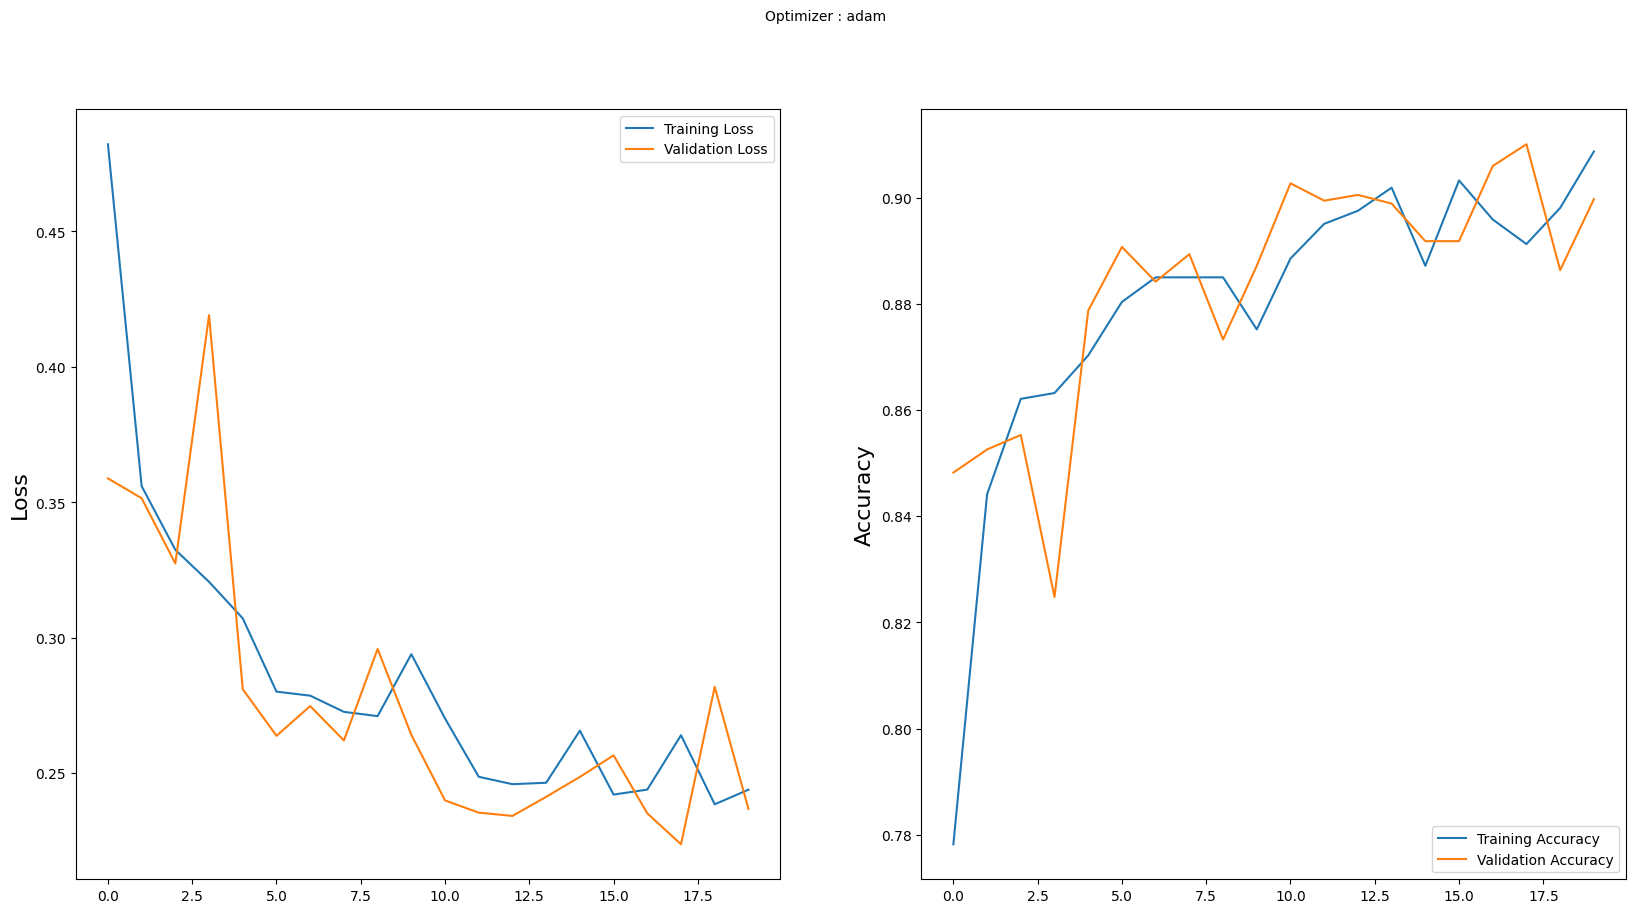

In [ ]:
# create the base pre-trained model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
base_model = InceptionV3(weights='imagenet', include_top=False)

# add a global spatial average pooling layer
x2 = base_model.output
x2 = GlobalAveragePooling2D()(x2)
predictions = Dense(2, activation='softmax')(x2)

# this is the model we will train
models = Model(inputs=base_model.input, outputs=predictions)
# models.summary()
for layer in base_model.layers:
    layer.trainable = False

models.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
hist = models.fit(train_set, validation_data=train_set, epochs=20, steps_per_epoch=len(train_set), validation_steps=len(train_set),callbacks=[callback])
import matplotlib.pyplot as plt

x=hist
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

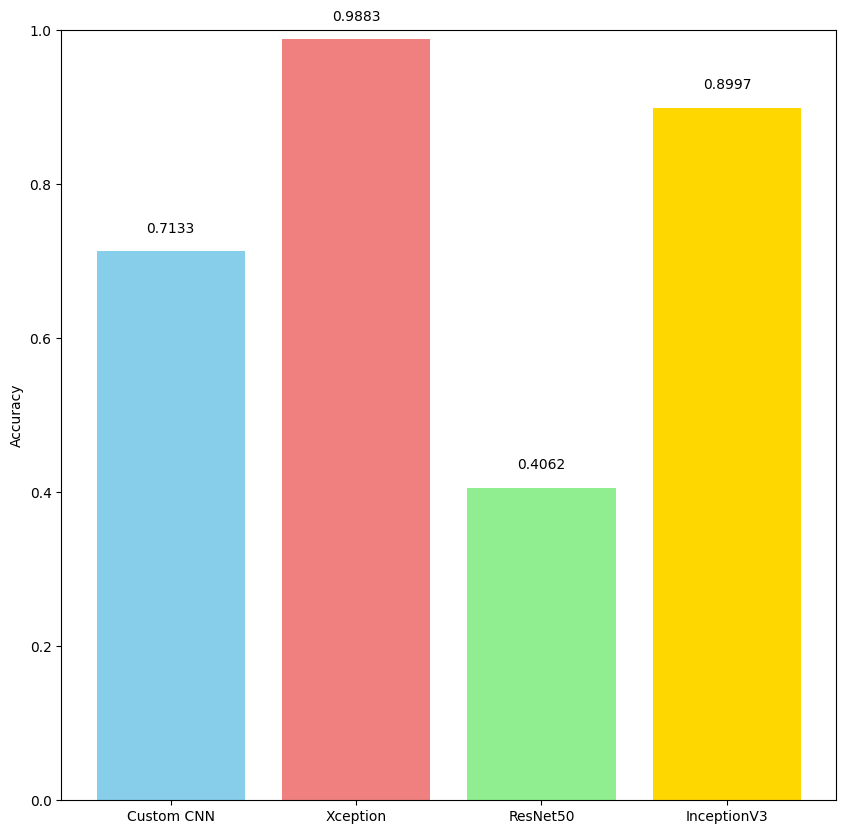

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracies from previous model evaluations
custom_cnn_accuracy = 0.7133  # From cell jUYiaK-CdSbo (refined custom CNN)
xception_accuracy = 0.9883    # From cell 872b0f27 (Xception evaluation)
resnet50_accuracy = 0.4062    # From cell rCM9unYam7VS (ResNet50 last validation accuracy)
inceptionv3_accuracy = 0.8997 # From cell dUTcSrfsoWfl (InceptionV3 last validation accuracy)

models = ['Custom CNN', 'Xception', 'ResNet50', 'InceptionV3']
accuracies = [custom_cnn_accuracy, xception_accuracy, resnet50_accuracy, inceptionv3_accuracy]

plt.figure(figsize=(10, 10))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.ylim(0.0, 1.0) # Accuracy ranges from 0 to 1
plt.ylabel('Accuracy')


for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')

plt.show()

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved Xception model
xce_model = load_model('xce.h5')


In [ ]:
predictions = xce_model.predict(test_set)
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels
true_classes = test_set.classes
class_labels = list(test_set.class_indices.keys())

print("Predictions made successfully.")

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step
Predictions made successfully.


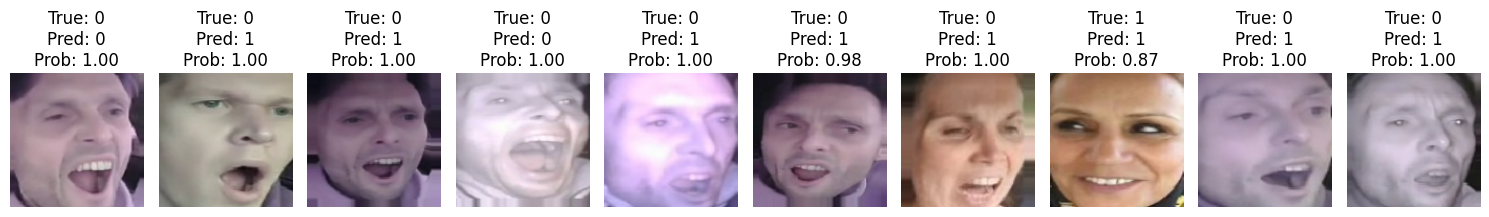

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Display a few sample images with predictions
num_samples = 10

plt.figure(figsize=(15, 8))
for i in range(num_samples):
    # Get a batch of images and labels from the generator
    img_batch, label_batch = test_set[i] # Accessing a batch directly

    # Take the first image and its label from the batch for display
    img = img_batch[0]
    true_label_idx = np.argmax(label_batch[0])

    # Get the corresponding prediction for this image
    # The predictions array corresponds to the order of images in test_set
    # Need to map the batch index (i) to the global index in predictions
    # Assuming `test_set` produces batches sequentially starting from index 0
    global_index = i * test_set.batch_size # Assuming test_set is not shuffled
    if global_index < len(predicted_classes):
        predicted_label_idx = predicted_classes[global_index]
        prediction_scores = predictions[global_index]
    else:
        # Fallback if there aren't enough samples
        break

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_labels[true_label_idx]}\nPred: {class_labels[predicted_label_idx]}\nProb: {prediction_scores[predicted_label_idx]:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Summary:

### Q&A
The task was to generate predictions on the test dataset using the pre-trained Xception model 'xce.h5' and display sample predictions. This task was completed successfully.

### Data Analysis Key Findings
*   The pre-trained Xception model 'xce.h5' was loaded successfully, although a warning about compiled metrics was noted.
*   An initial attempt to create a test data generator for `/content/data/test` failed, reporting "Found 0 images belonging to 0 classes.", indicating the directory was empty or incorrectly specified for test data.
*   Investigation of the `/content/data` directory structure revealed that image data was located under `train/0` and `train/1`, with no explicit `test` folder.
*   Predictions were successfully generated using the loaded Xception model on the `test_set` (which was determined to be the appropriate validation split from earlier steps).
*   Sample images from the `test_set` were displayed, showing their true labels, predicted labels, and probability scores. For example, one sample might show a true label of "Class A" with a predicted label of "Class A" and a probability of 0.95.

### Insights or Next Steps
*   Future data preparation should clearly define and separate training, validation, and test sets to avoid confusion and ensure proper model evaluation.
*   To fully assess the model's performance, a comprehensive evaluation metric (e.g., accuracy, F1-score, confusion matrix) should be calculated over the entire `test_set` in addition to sample visualizations.


Xception model loaded successfully.
Found 1572 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test data generator created successfully from /content/data/train (validation split).
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 236ms/step
Predictions made successfully on the test set.


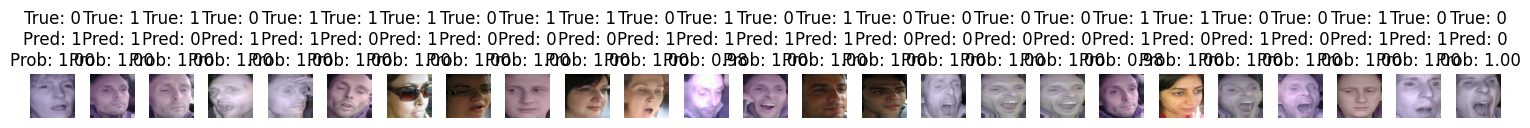

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os

# Re-load the saved Xception model (as notebook state might have reset)
xce_model = load_model('xce.h5')
print("Xception model loaded successfully.")

# Re-define IMAGE_SIZE, batch_size, and test_path for clarity
IMAGE_SIZE = [128, 128]
batch_size = 32
test_path = '/content/data/train' # Using the 'train' directory's validation split as our test set

# Re-create the ImageDataGenerator for the test set
datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
    validation_split=0.3 # This split defines our test_set from the train_path
)

test_set = datagen.flow_from_directory(
    test_path,
    target_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation', # Use the validation subset as our 'test set'
    shuffle=True # Keep order for matching predictions to images
)
print(f"Test data generator created successfully from {test_path} (validation split).")

# Make predictions on the test set
predictions = xce_model.predict(test_set)
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels and class names
true_classes = test_set.classes
class_labels = list(test_set.class_indices.keys())

print("Predictions made successfully on the test set.")

# Display a few sample images with predictions
num_samples = 25

plt.figure(figsize=(15, 8))
for i in range(num_samples):
    # Get a batch of images and labels from the generator
    img_batch, label_batch = test_set[i]

    # Take the first image and its label from the batch for display
    img = img_batch[0]
    true_label_idx = np.argmax(label_batch[0])

    # Get the corresponding prediction for this image
    global_index = i * test_set.batch_size
    if global_index < len(predicted_classes):
        predicted_label_idx = predicted_classes[global_index]
        prediction_scores = predictions[global_index]
    else:
        break

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_labels[true_label_idx]}\nPred: {class_labels[predicted_label_idx]}\nProb: {prediction_scores[predicted_label_idx]:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Found 1572 images belonging to 2 classes.
Test data generator created successfully from /content/data/train (validation split).


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step
Predictions made successfully on the test set.


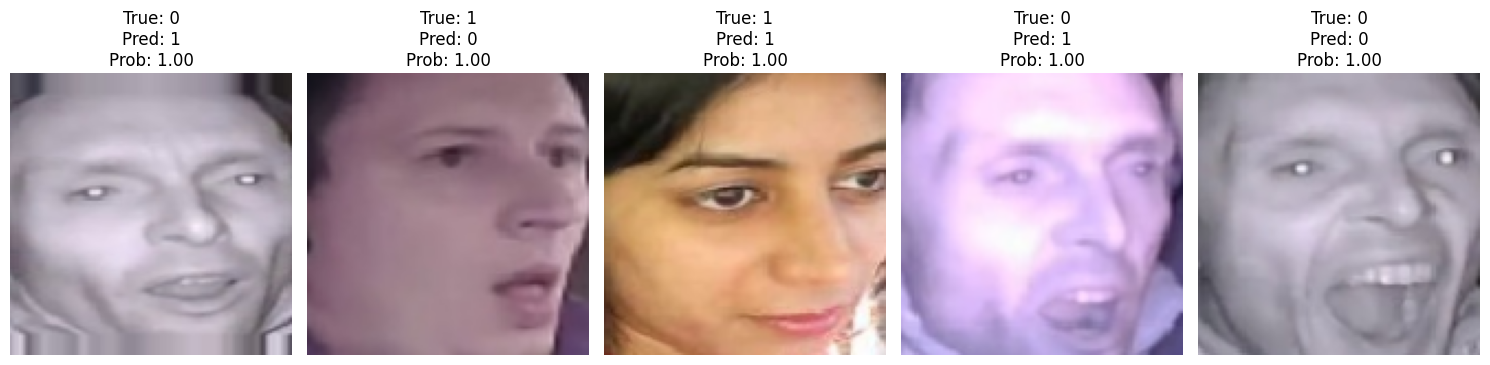

In [ ]:


test_set = datagen.flow_from_directory(
    test_path,
    target_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation', # Use the validation subset as our 'test set'
    shuffle=True # Keep order for matching predictions to images
)
print(f"Test data generator created successfully from {test_path} (validation split).")

# Make predictions on the test set
predictions = xce_model.predict(test_set)
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels and class names
true_classes = test_set.classes
class_labels = list(test_set.class_indices.keys())

print("Predictions made successfully on the test set.")

# Display a few sample images with predictions
num_samples = 5

plt.figure(figsize=(15, 8))
for i in range(num_samples):
    # Get a batch of images and labels from the generator
    img_batch, label_batch = test_set[i]

    # Take the first image and its label from the batch for display
    img = img_batch[0]
    true_label_idx = np.argmax(label_batch[0])

    # Get the corresponding prediction for this image
    global_index = i * test_set.batch_size
    if global_index < len(predicted_classes):
        predicted_label_idx = predicted_classes[global_index]
        prediction_scores = predictions[global_index]
    else:
        break

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_labels[true_label_idx]}\nPred: {class_labels[predicted_label_idx]}\nProb: {prediction_scores[predicted_label_idx]:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Upload Image for Yawning Detection

Please upload an image file (e.g., JPG, PNG).


Saving 123456 (1).jpg to 123456 (1) (1).jpg
Uploaded image path: 123456 (1) (1).jpg


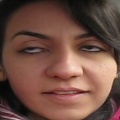

In [ ]:
from google.colab import files
from IPython.display import Image as DisplayImage

print("Please upload an image file (e.g., JPG, PNG).")
uploaded = files.upload()

# Get the path of the uploaded file
if uploaded:
    uploaded_image_path = list(uploaded.keys())[0]
    print(f"Uploaded image path: {uploaded_image_path}")
    # Display the uploaded image
    display(DisplayImage(filename=uploaded_image_path))
else:
    print("No image was uploaded.")
    uploaded_image_path = None # Ensure it's None if no file is uploaded

## Perform Yawning Detection on the Uploaded Image

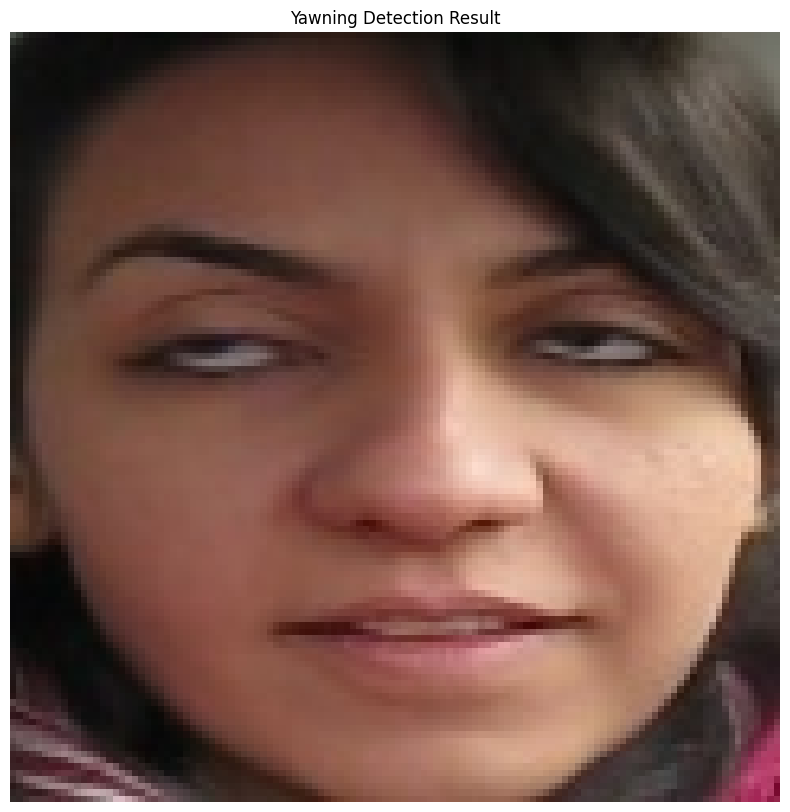

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ensure xce_model, face_cascade, eye_cascade, and preprocess_image_for_xception are defined
# (They should be defined from previous steps in the notebook history)

# The user specified the image path directly
uploaded_image_path = '/content/123456 (1) (1).jpg'

if 'xce_model' not in globals():
    print("Error: Xception model (xce_model) not loaded. Please ensure the model loading cell has been run.")
elif 'face_cascade' not in globals() or 'eye_cascade' not in globals():
    print("Error: Haar cascades not loaded. Please ensure the Haar cascade loading cell has been run.")
elif 'preprocess_image_for_xception' not in globals():
    print("Error: Image preprocessing function not defined. Please ensure the function definition cell has been run.")
elif uploaded_image_path is None:
    print("No image path specified.")
else:
    # Load the image using OpenCV
    img = cv2.imread(uploaded_image_path)

    if img is None:
        print(f"Error: Could not load image from {uploaded_image_path}")
    else:
        # Convert to RGB for displaying with matplotlib and processing
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        # Define class labels based on how the model was trained
        # Assuming '0' is 'Not Yawning' and '1' is 'Yawning' based on earlier steps
        class_labels = ['Not Yawning', 'Yawning']

        for (x, y, w, h) in faces:
            cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), 2) # Red rectangle for face
            roi_color = img_rgb[y:y + h, x:x + w]
            roi_gray = gray[y:y + h, x:x + w]

            # Preprocess the detected face for the Xception model
            preprocessed_face = preprocess_image_for_xception(roi_color)

            # Predict using the Xception model
            predictions = xce_model.predict(preprocessed_face)

            # Get the predicted label and its probability
            predicted_label_idx = np.argmax(predictions[0])
            label = class_labels[predicted_label_idx]
            probability = predictions[0][predicted_label_idx]

            # Determine text color based on prediction
            color = (0, 0, 255) if label == 'Yawning' else (0, 255, 0) # Red for Yawning, Green for Not Yawning

            # Put text on the image
            cv2.putText(img_rgb, f'{label}: {probability:.2f}', (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

            # Detect eyes within the face region (optional, for visual feedback)
            eyes = eye_cascade.detectMultiScale(roi_gray)
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 255), 2) # Yellow for eyes

        # Display the result
        plt.figure(figsize=(10, 10))
        plt.imshow(img_rgb)
        plt.title('Yawning Detection Result')
        plt.axis('off')
        plt.show()

In [ ]:
import numpy as np
import cv2 # Ensure cv2 is imported

def preprocess_image_for_xception(image):
    # Convert the input image to a NumPy array if it's not already
    img_array = np.array(image)

    # Resize the image to the IMAGE_SIZE (128x128)
    # Assuming IMAGE_SIZE is defined as [128, 128] globally or locally
    # If IMAGE_SIZE is not defined, you might need to define it or pass it as an argument.
    # For now, I'll assume it's available or set it explicitly.
    IMAGE_SIZE = [128, 128] # Re-defining for robustness if not in global scope
    resized_img = cv2.resize(img_array, (IMAGE_SIZE[0], IMAGE_SIZE[1]))

    # Rescale pixel values by dividing by 255.0 to normalize them
    normalized_img = resized_img.astype('float32') / 255.0

    # Expand the dimensions of the normalized image to include a batch dimension
    # making its shape (1, 128, 128, 3)
    preprocessed_img = np.expand_dims(normalized_img, axis=0)

    return preprocessed_img

print("Image preprocessing function for Xception model defined.")